# =========================================================
# 1) LINEAR ALGEBRA — EIGENVALUES / EIGENVECTORS
# =========================================================

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

def save_and_show(filename: str):
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()



A = np.array([[1.2, 0.1],
              [0.05, 1.1]], dtype=float)

eigvals, eigvecs = np.linalg.eig(A)

print("\n-----  Eigen Analysis -----")
print("Matrix A:\n", A)
print("Eigenvalues:", eigvals)
print("Eigenvectors (columns):\n", eigvecs)

years = np.arange(0, 21)
x0 = np.array([100.0, 80.0])

X = np.zeros((len(years), 2))
X[0] = x0

for i in range(1, len(years)):
    X[i] = A @ X[i - 1]


-----  Eigen Analysis -----
Matrix A:
 [[1.2  0.1 ]
 [0.05 1.1 ]]
Eigenvalues: [1.23660254 1.06339746]
Eigenvectors (columns):
 [[ 0.9390708  -0.59069049]
 [ 0.34372377  0.80689822]]


# =========================================================
# LINEAR ALGEBRA — PLOT (MATCHES REPORT FIGURE)
# =========================================================

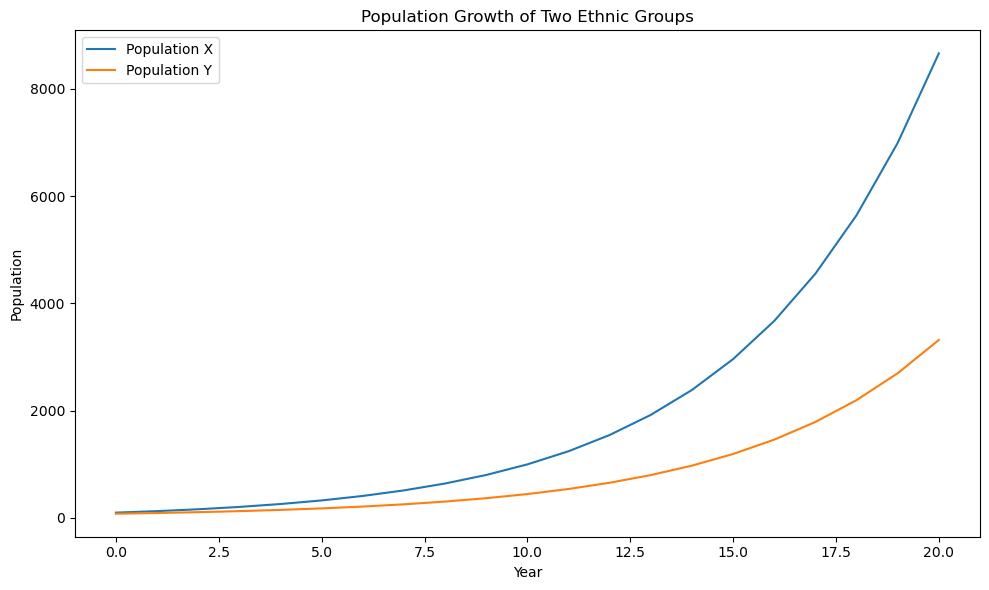

In [2]:

plt.figure(figsize=(10, 6))

plt.plot(years, X[:, 0], label="Population X")
plt.plot(years, X[:, 1], label="Population Y")

plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Population Growth of Two Ethnic Groups")

plt.legend()
plt.grid(False)   # report figure has no visible grid

save_and_show("fig_linear_algebra_population_growth.png")



# =========================================================
# 2) CALCULUS — GROWTH RATE + MAX VALUE
# =========================================================


----- Calculus: Growth Rate -----
P'(0) = 30.00
P'(20) = 54.66
Maximum growth rate on [0,20] occurs at t = 20


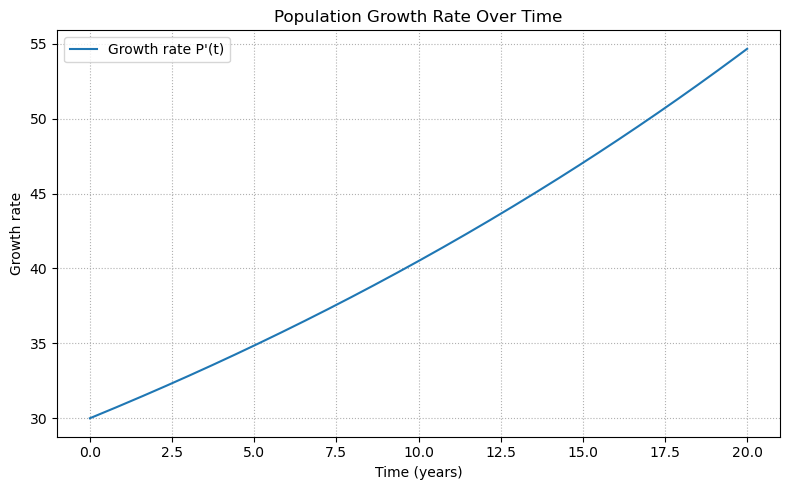

In [3]:




t = np.linspace(0, 20, 200)
P = 1000 * np.exp(0.03 * t)
P_prime = 30 * np.exp(0.03 * t)

print("\n----- Calculus: Growth Rate -----")
print(f"P'(0) = {P_prime[0]:.2f}")
print(f"P'(20) = {P_prime[-1]:.2f}")
print("Maximum growth rate on [0,20] occurs at t = 20")

plt.figure(figsize=(8, 5))
plt.plot(t, P_prime, label="Growth rate P'(t)")
plt.xlabel("Time (years)")
plt.ylabel("Growth rate")
plt.title("Population Growth Rate Over Time")
plt.grid(True, linestyle=":")
plt.legend()

save_and_show("fig_calculus_growth_rate.png")


# =========================================================
# 3) POISSON DISTRIBUTION
# =========================================================


----- Poisson Distribution -----
Mean = 5.0
Variance = 5.0
P(X=0) = 0.0067
P(X=5) = 0.1755
P(X<=5) = 0.6160


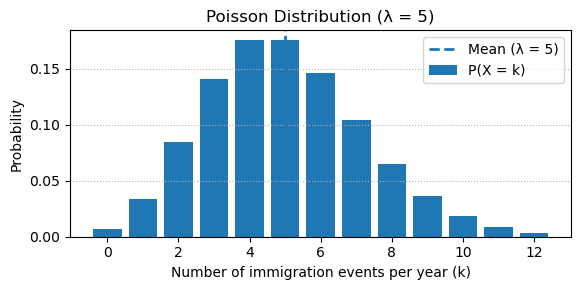

In [4]:

lam = 5.0
k = np.arange(0, 13)

pmf = np.array([math.exp(-lam) * lam**ki / math.factorial(int(ki)) for ki in k])

P0 = math.exp(-lam)
P5 = math.exp(-lam) * lam**5 / math.factorial(5)
P_le_5 = sum(pmf[:6])

print("\n----- Poisson Distribution -----")
print("Mean =", lam)
print("Variance =", lam)
print(f"P(X=0) = {P0:.4f}")
print(f"P(X=5) = {P5:.4f}")
print(f"P(X<=5) = {P_le_5:.4f}")

plt.figure(figsize=(6, 3))
plt.bar(k, pmf, label="P(X = k)")
plt.axvline(lam, linestyle="--", linewidth=2, label="Mean (λ = 5)")
plt.xlabel("Number of immigration events per year (k)")
plt.ylabel("Probability")
plt.title("Poisson Distribution (λ = 5)")
plt.grid(axis="y", linestyle=":")
plt.legend()

save_and_show("fig_poisson_pmf_lambda5.png")

# =========================================================
# 4) STATISTICS — MEAN, SD, 95% CI
# =========================================================


----- Statistical Summary -----
Sample size (n): 8
Sample mean (x̄): 1064.375
Sample standard deviation (s): 12.082
Standard error (SE): 4.272
t critical value: 2.365
Margin of error (ME): 10.103
95% Confidence interval: (1054.272, 1074.478)


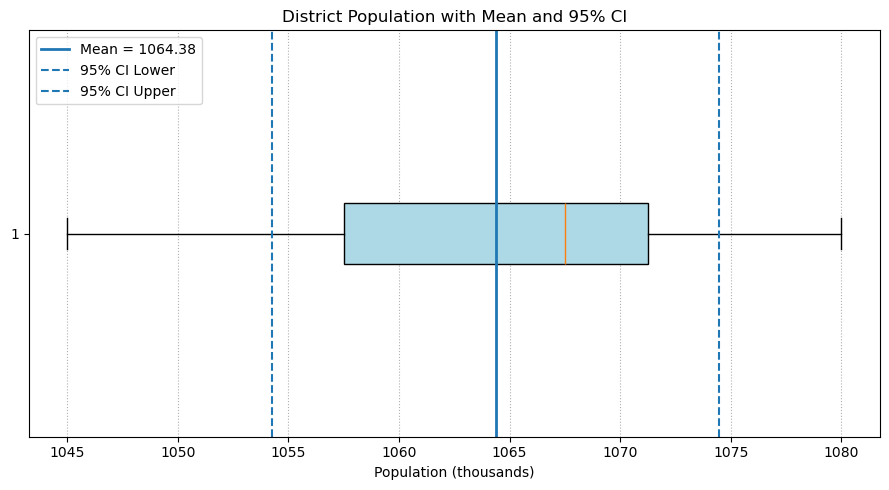


Saved figures:
 - fig_linear_algebra_population_growth.png
 - fig_calculus_growth_rate.png
 - fig_poisson_pmf_lambda5.png
 - fig_stats_boxplot_ci.png


In [5]:



data = np.array([1050, 1070, 1065, 1080, 1045, 1075, 1060, 1070], dtype=float)

n = len(data)
xbar = data.mean()
s = data.std(ddof=1)

t_crit = 2.365
SE = s / np.sqrt(n)
ME = t_crit * SE
ci_low = xbar - ME
ci_high = xbar + ME

print("\n----- Statistical Summary -----")
print(f"Sample size (n): {n}")
print(f"Sample mean (x̄): {xbar:.3f}")
print(f"Sample standard deviation (s): {s:.3f}")
print(f"Standard error (SE): {SE:.3f}")
print(f"t critical value: {t_crit}")
print(f"Margin of error (ME): {ME:.3f}")
print(f"95% Confidence interval: ({ci_low:.3f}, {ci_high:.3f})")

plt.figure(figsize=(9, 5))
plt.boxplot(data, vert=False, patch_artist=True,
            boxprops=dict(facecolor="lightblue"))

plt.axvline(xbar, linewidth=2, label=f"Mean = {xbar:.2f}")
plt.axvline(ci_low, linestyle="--", label="95% CI Lower")
plt.axvline(ci_high, linestyle="--", label="95% CI Upper")

plt.xlabel("Population (thousands)")
plt.title("District Population with Mean and 95% CI")
plt.grid(axis="x", linestyle=":")
plt.legend()

save_and_show("fig_stats_boxplot_ci.png")


# =========================================================
# FILE LIST FOR SCREENSHOT CHECK
# =========================================================
print("\nSaved figures:")
print(" - fig_linear_algebra_population_growth.png")
print(" - fig_calculus_growth_rate.png")
print(" - fig_poisson_pmf_lambda5.png")
print(" - fig_stats_boxplot_ci.png")
